# What Heiki actually asks for again

One-off, not part of the Visualizing the Unseen A/B threads. Source: `dada_science/library_recommender/library.db`, `user_ratings` where `user='heiki'` and `times_read > 0`. That table only stores running counters (times_read, reread_demands, false_starts) updated in place — no per-event timestamps — so this is a snapshot, not a timeline. Refreshed from the Pi (source of truth) 2026-08-17.

In [1]:
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

DB = "/home/simonhans/coding/dada_science/library_recommender/library.db"

con = sqlite3.connect(DB)
rows = con.execute("""
    SELECT b.title || CASE WHEN b.subtitle IS NOT NULL AND b.subtitle != '' THEN ' — ' || b.subtitle ELSE '' END,
           ur.times_read, ur.reread_demands, ur.false_starts, ur.avg_rating
    FROM user_ratings ur JOIN books b ON b.id = ur.book_id
    WHERE ur.user = 'heiki' AND ur.times_read > 0
    ORDER BY ur.times_read DESC
""").fetchall()
con.close()
len(rows), rows[:5]

(72,
 [('Every Night Is Pizza Night', 16, 6, 0, 5.0),
  ("Margret & H.A. Rey's Curious George and the Dump Truck", 16, 0, 0, 4.25),
  ("Pedro's Monster", 14, 0, 0, 4.0),
  ('Tractor Mac — Teamwork', 11, 8, 0, 5.0),
  ('The Lorax', 10, 4, 0, 5.0)])

In [2]:
titles, reads, rereads, false_starts, rating_raw = zip(*rows)
reads, rereads, false_starts = (np.array(x) for x in (reads, rereads, false_starts))
rating = np.array([np.nan if r is None else r for r in rating_raw], dtype=float)

reread_rate = rereads / reads
has_rating = ~np.isnan(rating)
r = np.corrcoef(reread_rate[has_rating], rating[has_rating])[0, 1]

assert len(rows) > 0
assert np.all(reread_rate >= 0)
assert -1 <= r <= 1

print(f"n={len(rows)} books, {reads.sum()} total reads, {(~has_rating).sum()} unrated, "
      f"rating<->reread-rate r={r:.3f}")

n=72 books, 355 total reads, 2 unrated, rating<->reread-rate r=0.336


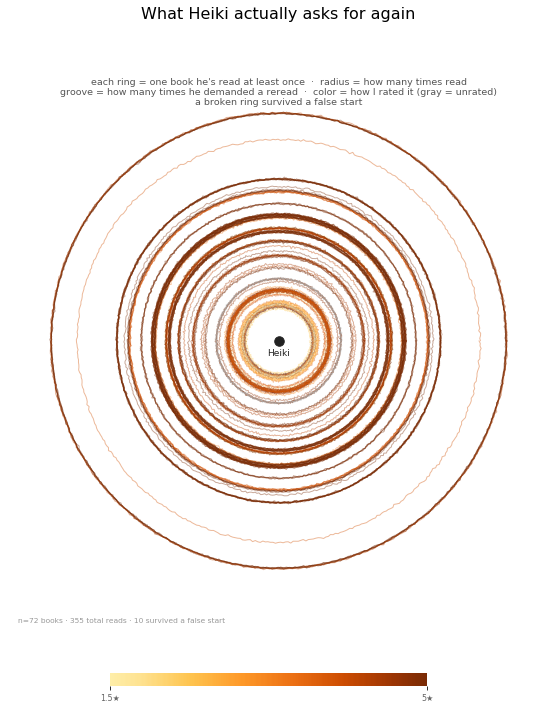

In [3]:
fig, ax = plt.subplots(figsize=(11, 11), subplot_kw={"aspect": "equal"})
rng = np.random.default_rng(7)

n = len(rows)
r_min, r_max = 1.0, 6.2
reads_f = reads.astype(float)
base = r_min + (reads_f - reads_f.min()) / (reads_f.max() - reads_f.min()) * (r_max - r_min)

# many books tie on times_read at this scale (72 books, reads 1-16) — bounded jitter instead
# of an exact spread, so ties separate visually without ever crossing into a neighboring tier
gap = (r_max - r_min) / (reads_f.max() - reads_f.min())
jitter = np.clip(rng.normal(0, gap * 0.18, size=n), -gap * 0.42, gap * 0.42)
radii = base + jitter

rating_norm = (rating - np.nanmin(rating)) / (np.nanmax(rating) - np.nanmin(rating))
# single-hue ramp (not viridis) — viridis's blue->green->yellow hue jump reads as discrete
# clusters for a continuous variable; a single hue avoids implying a categorical split
cmap = plt.cm.YlOrBr
COLOR_LO, COLOR_HI = 0.18, 0.95
GRAY = "#aaaaaa"  # unrated but still read

theta = np.linspace(0, 2 * np.pi, 500)
for i in range(n):
    passes = int(rereads[i]) + 1
    color = GRAY if np.isnan(rating[i]) else cmap(COLOR_LO + (COLOR_HI - COLOR_LO) * rating_norm[i])
    mask = np.ones_like(theta, dtype=bool)
    if false_starts[i] > 0:
        mask &= ~((theta > 0.9) & (theta < 1.05))  # a break marks books that survived a false start
    for _ in range(passes):
        wobble = radii[i] + rng.normal(0, 0.015, size=theta.shape)
        ax.plot(wobble[mask] * np.cos(theta[mask]), wobble[mask] * np.sin(theta[mask]),
                color=color, alpha=0.4, linewidth=1.0, solid_capstyle="round")

for r_ref in (r_min, r_max):
    ax.plot(r_ref * np.cos(theta), r_ref * np.sin(theta), color="#cccccc",
             linewidth=0.7, linestyle=(0, (1, 3)), zorder=0)

ax.scatter([0], [0], s=90, color="#222222", zorder=5)
ax.annotate("Heiki", (0, 0), xytext=(0, -14), textcoords="offset points",
            fontsize=9, ha="center", color="#222222")

# rating colorbar, standalone axis so it doesn't fight the polar layout
cax = fig.add_axes([0.30, 0.06, 0.4, 0.016])
grad = np.linspace(COLOR_LO, COLOR_HI, 256).reshape(1, -1)
cax.imshow(grad, aspect="auto", cmap=cmap, vmin=0, vmax=1,
           extent=[np.nanmin(rating), np.nanmax(rating), 0, 1])
cax.set_yticks([])
cax.set_xticks([np.nanmin(rating), np.nanmax(rating)])
cax.set_xticklabels([f"{np.nanmin(rating):g}★", f"{np.nanmax(rating):g}★"], fontsize=8, color="#666666")
for s in cax.spines.values():
    s.set_visible(False)

ax.set_title("What Heiki actually asks for again", fontsize=16, pad=18)
ax.text(0, r_max + 1.0,
        "each ring = one book he's read at least once  ·  radius = how many times read\n"
        "groove = how many times he demanded a reread  ·  color = how I rated it (gray = unrated)\n"
        "a broken ring survived a false start",
        ha="center", va="top", fontsize=9.5, color="#555555")
ax.text(0.02, 0.02, f"n={n} books · {reads.sum()} total reads · {(false_starts > 0).sum()} survived a false start",
        transform=ax.transAxes, fontsize=7.5, color="#999999")

lim = r_max + 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim - 0.6, lim + 0.9)
ax.axis("off")

fig.savefig("heiki_reading_life.png", dpi=200, bbox_inches="tight")
plt.show()